# Ordinal DCM: GWT Status Update

**What changed:** The original DCM collapsed expert probability judgements into binary (present/absent) via a Monte Carlo simulation loop, which was slow and discarded graded information. We replaced this with an **ordinal observation model** that directly uses 7-point ratings (e.g. Likert scale), fitting all expert responses simultaneously.

**Why it matters:** Ordinal ratings preserve more information, are cheaper to collect, and eliminate the simulation outer loop entirely. The model marginalises over the latent indicator state analytically, so the posterior for the headline quantity — $P(\text{consciousness} = 1 \mid \text{data})$ — properly propagates uncertainty from the expert ratings through the full hierarchy.

**This notebook:** Verification on GWT / 2024 Leading Chat LLMs data, with convergence diagnostics and sanity checks.

In [1]:
import sys, os

sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))

import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

from dcm_model import (
    ModelConfig,
    OrdinalDataProcessor,
    EvidenceProcessor,
    BayesianModelBuilder,
    ResultsManager,
    load_data,
    node_key,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

---
## 1. Data and model fit

In [2]:
config = ModelConfig(
    NUM_SAMPLES=1000,
    NUM_TUNE=1000,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.95,
)

all_data = load_data(config)
stance_data = next(s for s in all_data if s["name"] == config.TARGET_STANCE)

processor = OrdinalDataProcessor(config)
processor.process(stance_data, config.TARGET_SYSTEM)

# Anonymise experts for sharing
import string

anon_names = {
    name: f"Expert {letter}"
    for letter, name in zip(string.ascii_uppercase, processor.expert_names)
}

print(f"Experts: {list(anon_names.values())}")
print(f"Anchor expert: {anon_names[processor.anchor_expert]}")
print(f"Indicators with observations: {len(processor.observations)}")
print(f"Total ratings: {sum(len(v) for v in processor.observations.values())}")

Experts: ['Expert A', 'Expert B', 'Expert C', 'Expert D']
Anchor expert: Expert A
Indicators with observations: 50
Total ratings: 186


In [3]:
evidence_proc = EvidenceProcessor(config)
builder = BayesianModelBuilder(config, evidence_proc, processor)
model = builder.build_model(stance_data)
idata = builder.sample(model)

Initializing NUTS using jitter+adapt_diag...
/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representati

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 118 seconds.


---
## 2. Convergence diagnostics

Standard MCMC checks: all $\hat{R}$ values should be < 1.01 and effective sample sizes (ESS) should be in the hundreds+.

In [4]:
rhat = az.rhat(idata)
max_rhat = max(float(rhat[v].max()) for v in rhat.data_vars)
ess = az.ess(idata)
min_ess = min(float(ess[v].min()) for v in ess.data_vars)

print(f"Max Rhat:  {max_rhat:.4f}  {'OK' if max_rhat < 1.01 else 'WARNING'}")
print(f"Min ESS:   {min_ess:.0f}  {'OK' if min_ess > 100 else 'WARNING'}")

Max Rhat:  1.0045  OK
Min ESS:   1935  OK


---
## 3. Headline result: P(consciousness = 1)

The top-level quantity of interest. The stance prior is $\text{Beta}(1, 5)$ (mildly skeptical); the posterior is updated by the full hierarchy of feature/indicator evidence.

P(consciousness = 1 | data) = 0.143
94% HDI: [0.005, 0.448]


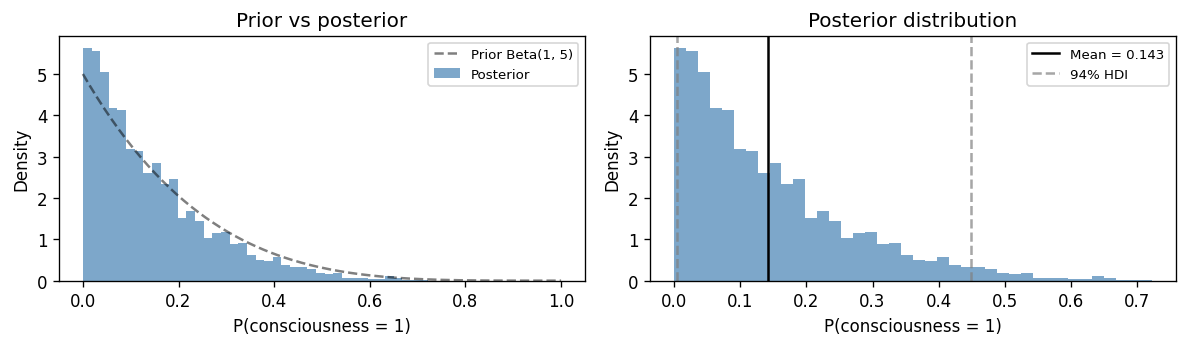

In [ ]:
# Stance-level posterior
stance_varname = builder.node_to_varname[config.TARGET_STANCE]
stance_p = idata.posterior[f"{stance_varname}_beta"].values.flatten()

print(f"P(consciousness = 1 | data) = {stance_p.mean():.3f}")
print(f"94% HDI: [{np.percentile(stance_p, 3):.3f}, {np.percentile(stance_p, 97):.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Prior vs posterior
from scipy.stats import beta as beta_dist

x = np.linspace(0, 1, 200)
axes[0].plot(
    x,
    beta_dist.pdf(x, config.DEFAULT_ALPHA, config.DEFAULT_BETA),
    "k--",
    alpha=0.5,
    label=f"Prior Beta({config.DEFAULT_ALPHA}, {config.DEFAULT_BETA})",
)
axes[0].hist(
    stance_p, bins=40, density=True, color="steelblue", alpha=0.7, label="Posterior"
)
axes[0].set_xlabel("P(consciousness = 1)")
axes[0].set_ylabel("Density")
axes[0].set_title("Prior vs posterior")
axes[0].legend(fontsize=8)

# Posterior density (zoomed)
axes[1].hist(stance_p, bins=40, density=True, color="steelblue", alpha=0.7)
axes[1].axvline(
    stance_p.mean(),
    color="black",
    linestyle="-",
    linewidth=1.5,
    label=f"Mean = {stance_p.mean():.3f}",
)
axes[1].axvline(np.percentile(stance_p, 3), color="grey", linestyle="--", alpha=0.7)
axes[1].axvline(
    np.percentile(stance_p, 97),
    color="grey",
    linestyle="--",
    alpha=0.7,
    label="94% HDI",
)
axes[1].set_xlabel("P(consciousness = 1)")
axes[1].set_ylabel("Density")
axes[1].set_title("Posterior distribution")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 4. Observation model: cutpoints and expert shifts

The ordinal model estimates shared **cutpoints** $\kappa$ (thresholds on a latent scale mapping to the 7-point rating) and per-expert **shifts** $b_e$ capturing how lenient or strict each expert is. The **discrimination** $a$ governs how well the scale separates present from absent indicators. One expert is anchored at $b = 0$ for identifiability.

Discrimination (a): 1.45
Cutpoints (kappa): [-0.35  0.13  0.49  1.02  1.46  2.12]

  Expert A: shift = +0.00  (neutral) (anchor)
  Expert B: shift = +0.12  (more lenient)
  Expert C: shift = +0.26  (more lenient)
  Expert D: shift = +0.44  (more lenient)


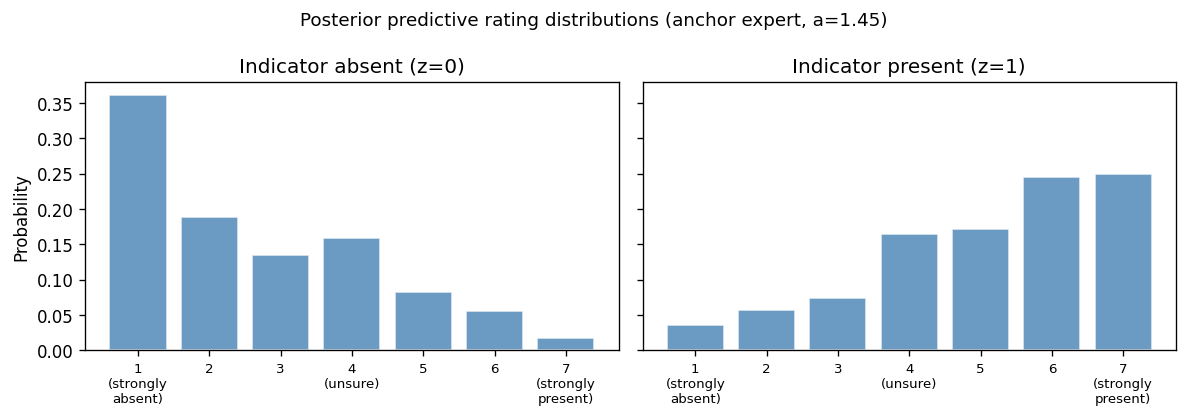

In [6]:
a_mean = float(idata.posterior["a"].mean())
kappa_mean = idata.posterior["kappa"].mean(dim=("chain", "draw")).values
n_experts = len(processor.expert_names)

# Expert shifts: anchor is 0 by construction
b_vals = np.zeros(n_experts)
if "b_free" in idata.posterior:
    b_free = idata.posterior["b_free"].mean(dim=("chain", "draw")).values
    b_vals[1:] = b_free

print(f"Discrimination (a): {a_mean:.2f}")
print(f"Cutpoints (kappa): {np.array2string(kappa_mean, precision=2)}")
print()
for i, name in enumerate(processor.expert_names):
    tag = " (anchor)" if i == 0 else ""
    direction = (
        "neutral"
        if abs(b_vals[i]) < 0.1
        else ("more lenient" if b_vals[i] > 0 else "stricter")
    )
    print(f"  {anon_names[name]}: shift = {b_vals[i]:+.2f}  ({direction}){tag}")


# Implied rating distributions for z=0 (absent) vs z=1 (present)
def category_probs(kappa, eta, K=7):
    cum = np.concatenate([[0], stats.norm.cdf(kappa - eta), [1]])
    return np.diff(cum)


fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
cats = np.arange(7)
labels = [
    "1\n(strongly\nabsent)",
    "2",
    "3",
    "4\n(unsure)",
    "5",
    "6",
    "7\n(strongly\npresent)",
]

for ax, (title, shift) in zip(
    axes, [("Indicator absent (z=0)", 0), ("Indicator present (z=1)", a_mean)]
):
    probs = category_probs(kappa_mean, b_vals[0] + shift)
    ax.bar(cats, probs, color="steelblue", alpha=0.8, edgecolor="white")
    ax.set_xticks(cats)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Probability" if ax == axes[0] else "")

fig.suptitle(
    f"Posterior predictive rating distributions (anchor expert, a={a_mean:.2f})",
    fontsize=11,
)
fig.tight_layout()
plt.show()

---
## 5. Indicator posteriors: $P(z_j = 1 \mid \text{data})$

For each indicator, the model marginalises over the latent state $z_j \in \{0, 1\}$ (absent/present), combining the prior from the tree hierarchy with the ordinal likelihood from expert ratings. Values near 1 mean strong posterior evidence of presence; near 0 mean absence.

In [7]:
# Collect all indicator posteriors
indicator_results = []
for nkey, varname in builder.node_to_varname.items():
    pz1_name = f"{varname}_pz1"
    if pz1_name not in idata.posterior:
        continue
    draws = idata.posterior[pz1_name].values.flatten()
    obs_list = processor.observations.get(nkey, [])
    ratings = [r for _, r in obs_list]
    indicator_results.append(
        {
            "name": nkey.split(" > ")[-1],
            "path": nkey,
            "mean": float(draws.mean()),
            "hdi_low": float(np.percentile(draws, 3)),
            "hdi_high": float(np.percentile(draws, 97)),
            "n_obs": len(obs_list),
            "mean_rating": float(np.mean(ratings)) if ratings else np.nan,
        }
    )

indicator_results.sort(key=lambda r: r["mean"], reverse=True)

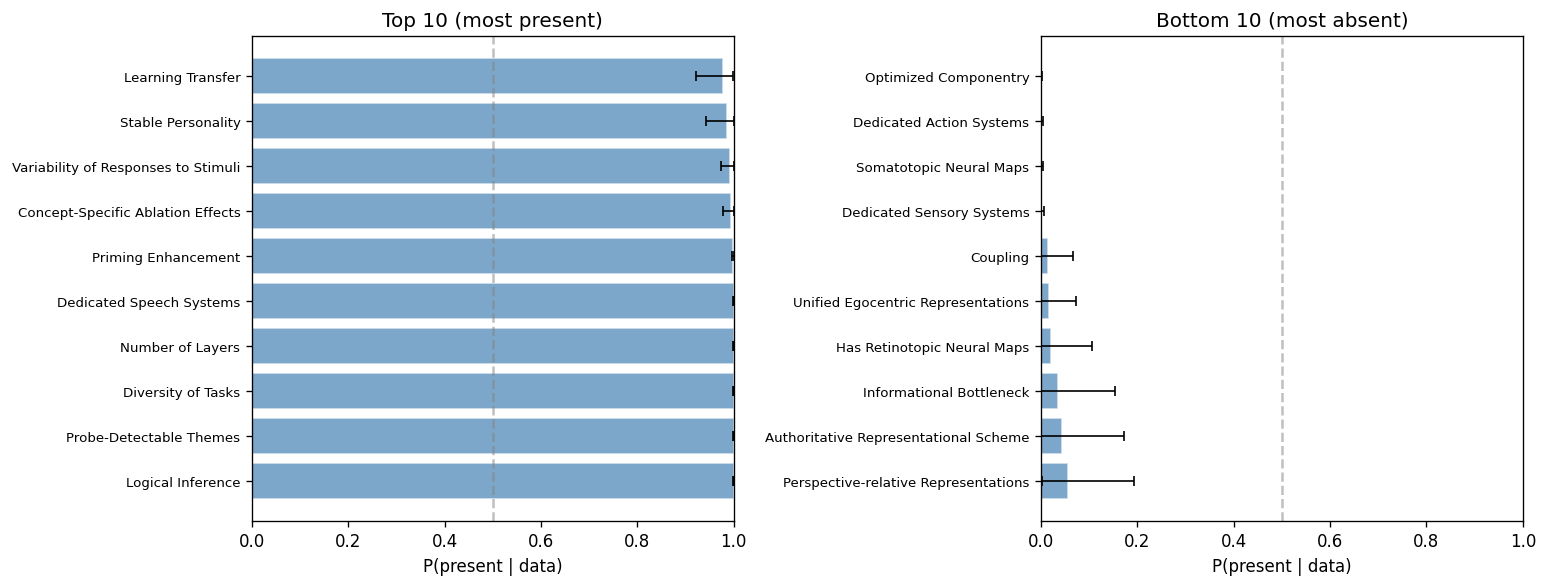

In [8]:
# Top 10 and bottom 10
n_show = 10
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, subset, title in [
    (axes[0], indicator_results[:n_show], f"Top {n_show} (most present)"),
    (axes[1], indicator_results[-n_show:], f"Bottom {n_show} (most absent)"),
]:
    names = [r["name"][:40] for r in subset]
    means = [r["mean"] for r in subset]
    lows = [r["hdi_low"] for r in subset]
    highs = [r["hdi_high"] for r in subset]
    y = np.arange(len(subset))

    ax.barh(y, means, color="steelblue", alpha=0.7, edgecolor="white")
    ax.errorbar(
        means,
        y,
        xerr=[np.array(means) - lows, np.array(highs) - means],
        fmt="none",
        color="black",
        capsize=3,
        linewidth=1,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel("P(present | data)")
    ax.set_title(title)
    ax.axvline(0.5, color="grey", linestyle="--", alpha=0.5)

fig.tight_layout()
plt.show()

In [9]:
# Full table
print(
    f"{'Indicator':<45} {'P(present)':>10} {'94% CI':>14} {'n':>3}  {'Avg rating':>10}"
)
print("-" * 95)
for r in indicator_results:
    print(
        f"{r['name'][:44]:<45} {r['mean']:>10.3f} "
        f"[{r['hdi_low']:.2f}, {r['hdi_high']:.2f}] "
        f"{r['n_obs']:>3}  {r['mean_rating']:>10.1f}"
    )

Indicator                                     P(present)         94% CI   n  Avg rating
-----------------------------------------------------------------------------------------------
Logical Inference                                  1.000 [1.00, 1.00]   4         6.0
Probe-Detectable Themes                            1.000 [1.00, 1.00]   4         6.0
Diversity of Tasks                                 1.000 [1.00, 1.00]   4         5.8
Number of Layers                                   1.000 [1.00, 1.00]   4         6.0
Dedicated Speech Systems                           1.000 [1.00, 1.00]   4         6.0
Priming Enhancement                                0.999 [1.00, 1.00]   4         5.5
Concept-Specific Ablation Effects                  0.995 [0.98, 1.00]   4         5.0
Variability of Responses to Stimuli                0.993 [0.97, 1.00]   3         5.0
Stable Personality                                 0.986 [0.94, 1.00]   4         4.8
Learning Transfer                         

---
## 6. Sanity check: do posteriors track raw ratings?

If the model is well-calibrated, indicators with higher average expert ratings should have higher $P(z_j = 1 \mid \text{data})$. A strong monotonic relationship here is necessary (though not sufficient) for the model to be sensible.

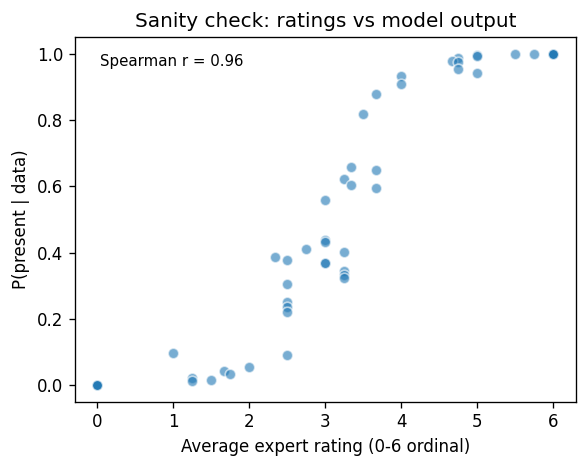

In [10]:
avg_ratings = [
    r["mean_rating"] for r in indicator_results if not np.isnan(r["mean_rating"])
]
pz1_vals = [r["mean"] for r in indicator_results if not np.isnan(r["mean_rating"])]

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(avg_ratings, pz1_vals, alpha=0.6, edgecolor="white", s=40)
ax.set_xlabel("Average expert rating (0-6 ordinal)")
ax.set_ylabel("P(present | data)")
ax.set_title("Sanity check: ratings vs model output")

# Correlation
r_val, p_val = stats.spearmanr(avg_ratings, pz1_vals)
ax.annotate(
    f"Spearman r = {r_val:.2f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=9
)

fig.tight_layout()
plt.show()

---
## 7. Feature-level posteriors

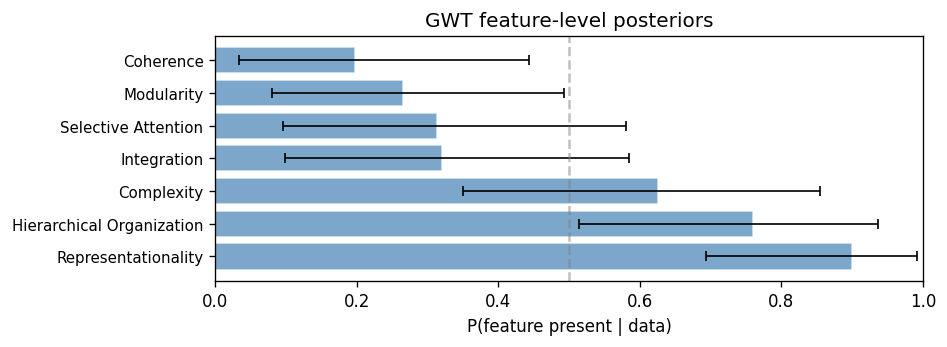

In [11]:
feature_results = []
for nkey, varname in builder.node_to_varname.items():
    bern_name = f"{varname}_bern"
    if bern_name not in idata.posterior:
        continue
    parts = nkey.split(" > ")
    depth = len(parts) - 1
    if depth != 1:  # top-level features only
        continue
    draws = idata.posterior[bern_name].values.flatten()
    feature_results.append(
        {
            "name": parts[-1],
            "mean": float(draws.mean()),
            "hdi_low": float(np.percentile(draws, 3)),
            "hdi_high": float(np.percentile(draws, 97)),
        }
    )

feature_results.sort(key=lambda r: r["mean"], reverse=True)

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(feature_results))))
y = np.arange(len(feature_results))
means = [r["mean"] for r in feature_results]
lows = [r["hdi_low"] for r in feature_results]
highs = [r["hdi_high"] for r in feature_results]
names = [r["name"][:50] for r in feature_results]

ax.barh(y, means, color="steelblue", alpha=0.7, edgecolor="white")
ax.errorbar(
    means,
    y,
    xerr=[np.array(means) - lows, np.array(highs) - means],
    fmt="none",
    color="black",
    capsize=3,
    linewidth=1,
)
ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("P(feature present | data)")
ax.set_title("GWT feature-level posteriors")
ax.axvline(0.5, color="grey", linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

---
## 8. Next steps

This is the first-pass ordinal model. Extensions to consider:

1. **Expert-specific cutpoints** -- Currently all experts share the same cutpoints $\kappa$. Different experts may interpret the scale differently, so allowing individual cutpoints per expert could improve model fit.

2. **Expert-specific discrimination** -- The discrimination parameter $a$ is currently shared. Making this per-expert would let the model account for experts who are more or less decisive.

3. **Native Likert data collection** -- The current data was converted from legacy continuous probabilities to ordinal categories. Collecting ratings directly on a 7-point scale in future surveys would remove this conversion step and give cleaner data.

4. **Posterior predictive checks** -- More rigorous comparison of model-predicted rating distributions against observed ratings, broken down by expert and indicator.

5. **Sensitivity analysis** -- How much do posteriors (especially $P(\text{consciousness} = 1)$) change under different priors or different numbers of rating categories?

6. **Extend beyond GWT** -- Apply the ordinal model to other stances (currently only GWT is implemented).